In [2]:
import pandas as pd
import numpy as np
from tqdm.notebook import tqdm
from pathlib import Path
from matplotlib import pyplot as plt
import importlib
from plotly import graph_objects as go
from plotly.subplots import make_subplots

import sys
sys.path.append('../')
from functions import draw_layout_compparison, draw_conditional_connection_probability, draw_clogging_representation

In [3]:
graph_path = Path('../graphs')
graphs = pd.read_csv(graph_path.joinpath('meta.csv'))

def load_graph(name: str, coords: bool = True, graph_path: Path = graph_path):
    adjacency_matrix = np.load(graph_path.joinpath(f'adjacency_matrices/{name}.npy'))
    coord = np.load(graph_path.joinpath(f'coordinates/{name}.npy'))
    return adjacency_matrix, coord

model_path = Path('../models/')
models = pd.read_csv(model_path.joinpath('meta.csv'))

def load_model(name: str):
    name = 'baseline'
    return importlib.import_module(f'models.{name}').embed

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [00:12<00:00, 815.81it/s]


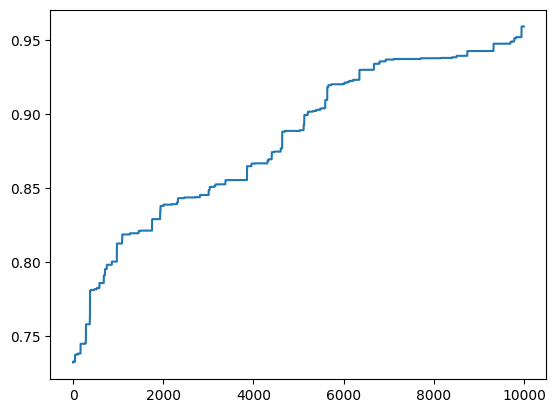

In [3]:
adjacency_matrix, coord_orig = load_graph('pso_128')
model = load_model('baseline')
log, coord_emb = model(adjacency_matrix, coord=coord_orig, steps=1e4, verbose=True)
_ = plt.plot(log)

In [65]:
distance = get_distance(coord)
adjacency_list = np.array([np.where(neigh)[0] for neigh in adjacency_matrix], dtype=object)
N = adjacency_matrix.shape[0]
num_grs_iter = int(np.ceil(np.log2(N-1)))
gcn = greedy_closest_neighbour(adjacency_list, distance)
gd = greedy_destination(gcn.copy(), num_grs_iter)
gd = drip_down(gcn, gd, distance)
clogging_count = np.bincount(gd.flatten()) - np.sum(gd == np.arange(N), axis=0)

In [6]:
#adjacency_matrix, coord = graphs['pso_512']
adjacency_matrix, coord = graphs['pso_128']
adjacency_list = np.array([np.where(neigh)[0] for neigh in adjacency_matrix], dtype=object)
N = adjacency_matrix.shape[0]
arange = np.arange(N)
num_grs_iter = int(np.ceil(np.log2(N-1)))

#coord = get_random_init(adjacency_matrix)


dist = get_distance(coord)
gcn = greedy_closest_neighbour(adjacency_list, dist)
gd = greedy_destination(gcn.copy(), num_grs_iter)
grs = greedy_routing_score(gd)

In [7]:
moved_vertex = np.random.randint(N)
new_coord = random_move(coord.copy(), moved_vertex)
new_dist = get_distance(new_coord)
new_gcn_alt = greedy_closest_neighbour(adjacency_list, new_dist)
new_gd_alt = greedy_destination(new_gcn_alt.copy(), num_grs_iter)

In [ ]:
distance = new_dist.copy()
moved_vertex_neighbours = adjacency_list[moved_vertex]
moved_vertex, moved_vertex_neighbours

(117, array([46, 80]))

In [8]:
def recalc_greedy_routing(adjacency_list, distance, num_grs_iter, gcn, gd, moved_vertex):
    N = adjacency_list.shape[0]
    
    affected = np.append(adjacency_list[moved_vertex], moved_vertex)
    affected_next_hop = np.array([neighbours[np.argmin(distance[neighbours], axis=0)] for neighbours in adjacency_list[affected]])
    affected_next_hop[np.arange(affected.shape[0]), affected] = affected
    changed = np.any(affected_next_hop != gcn[affected], axis=0)
    new_gcn = gcn.copy()
    
    new_gcn[:, moved_vertex] = np.array([neighbours[np.argmin(distance[neighbours, moved_vertex], axis=0)] for neighbours in adjacency_list])
    new_gcn[affected] = affected_next_hop
    
    changed[moved_vertex] = True
    new_gd = gd.copy()
    new_gd[:, changed] = greedy_destination(new_gcn[:, changed], num_grs_iter)
    return new_gcn, new_gd

In [9]:
affected = np.append(adjacency_list[moved_vertex], moved_vertex)
affected_next_hop = np.array([neighbours[np.argmin(distance[neighbours], axis=0)] for neighbours in adjacency_list[affected]])
affected_next_hop[np.arange(affected.shape[0]), affected] = affected

new_gcn = gcn.copy()
new_gcn[:, moved_vertex] = np.array([neighbours[np.argmin(distance[neighbours, moved_vertex], axis=0)] for neighbours in adjacency_list])
new_gcn[affected] = affected_next_hop

In [10]:
prev_affected_next_hop = gcn[affected]

In [13]:
changed = affected_next_hop != prev_affected_next_hop

In [14]:
source, target = np.where(changed)
source = affected[source]